# **Business Understanding**

**Problem:**
Banks need to identify which clients are likely to subscribe to a bank product to avoid unnecessary marketing costs.

**Goal:**
Predict whether a client will subscribe to a term deposit (deposit = yes/no).

**Type:**
Binary Classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats.mstats import winsorize
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score


# **Data Exploration**

In [2]:
df=pd.read_csv("/content/bank.csv")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [3]:
df.shape

(11162, 17)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,11162.0,41.231948,11.913369,18.0,32.0,39.0,49.00,95.0
balance,11162.0,1528.538524,3225.413326,-6847.0,122.0,550.0,1708.00,81204.0
day,11162.0,15.658036,8.420740,1.0,8.0,15.0,22.00,31.0
duration,11162.0,371.993818,347.128386,2.0,138.0,255.0,496.00,3881.0
campaign,11162.0,2.508421,2.722077,1.0,1.0,2.0,3.00,63.0
pdays,11162.0,51.330407,108.758282,-1.0,-1.0,-1.0,20.75,854.0
previous,11162.0,0.832557,2.292007,0.0,0.0,0.0,1.00,58.0


In [6]:
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,poutcome,deposit
count,11162,11162,11162,11162,11162,11162,11162,11162,11162,11162
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,no,no,cellular,may,unknown,no
freq,2566,6351,5476,10994,5881,9702,8042,2824,8326,5873


In [7]:
df.columns



Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

In [8]:
df["deposit"].value_counts()

,count
deposit,
no,5873
yes,5289


In [9]:
df.select_dtypes(include="object").columns


Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'deposit'],
      dtype='object')

In [10]:
df.select_dtypes(include="number").columns

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')

In [11]:
df.isnull().sum()



,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [12]:
# count unknowns
for col in df.columns:
    if df[col].dtype == "object":
        print(col, df[col].value_counts().get("unknown", 0))

job 70
marital 0
education 497
default 0
housing 0
loan 0
contact 2346
month 0
poutcome 8326
deposit 0


In [13]:
df.duplicated().sum()

np.int64(0)

## **Data Understanding**
**✅ No missing values (NaN) were found.**

**✅ No duplicate records were detected.**

**Some categorical features contain the value "unknown", which represents unavailable information rather than missing data.**

**Overall, the dataset is complete and suitable for further analysis.**

**Initial Observations**

**The target variable (deposit) is a balanced binary classification problem.**

**Most customers are middle-aged, married, and have secondary education.**

**Account balances include negative values and show high variability.**

**Features such as balance, campaign, pdays, and duration contain extreme values that require further investigation during EDA.**

# **EDA**

deposit
no     5873
yes    5289
Name: count, dtype: int64


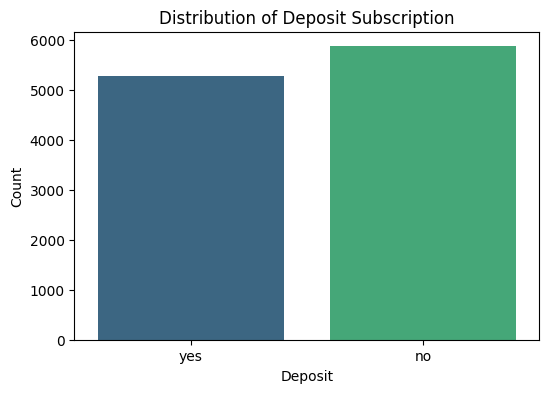

In [14]:

print(df['deposit'].value_counts())
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='deposit',
    hue='deposit',
    palette='viridis',
    legend=False
)

plt.title("Distribution of Deposit Subscription")
plt.xlabel("Deposit")
plt.ylabel("Count")

plt.show()

**The dataset appears relatively balanced between customers who subscribed and those who did not, indicating that severe class imbalance is not expected during model training.**

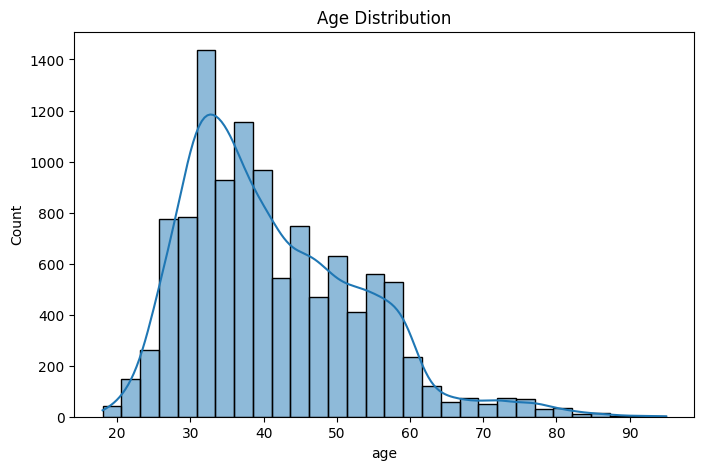

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="age",
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.show()

**The majority of customers are middle-aged (approximately 30–40 years old). The age distribution is positively skewed, indicating that younger and middle-aged customers make up most of the bank's customer base, while older customers represent a smaller proportion.**

/tmp/ipykernel_18128/2607251035.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Axes: xlabel='deposit', ylabel='age'>

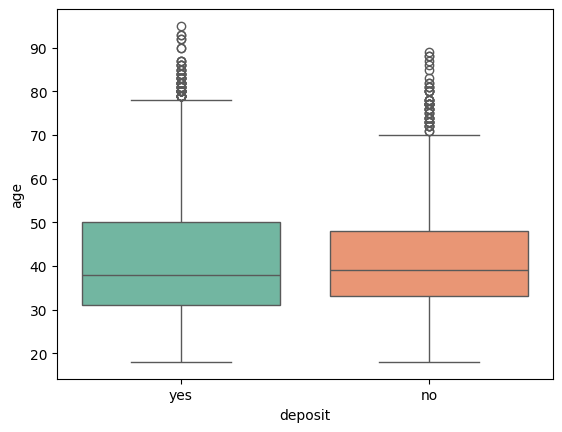

In [16]:
sns.boxplot(
    data=df,
    x="deposit",
    y="age",
 palette="Set2"

)

<Axes: xlabel='count', ylabel='job'>

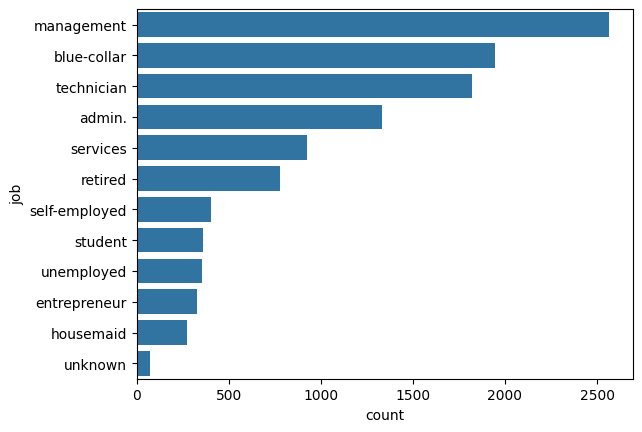

In [17]:
sns.countplot(
    data=df,
    y="job",
    order=df["job"].value_counts().index
)

<Axes: xlabel='count', ylabel='job'>

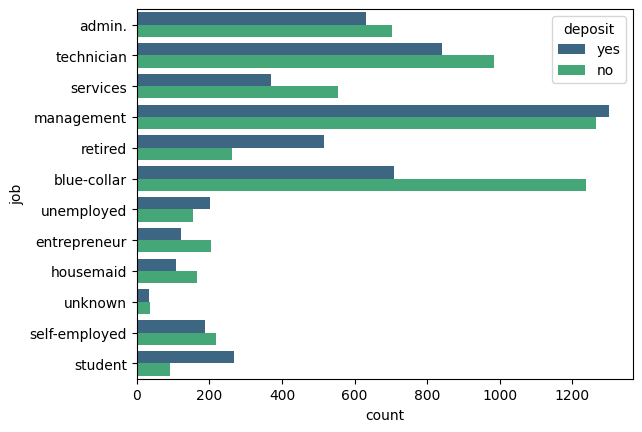

In [18]:
sns.countplot(
    data=df,
    y="job",
    hue="deposit",
    palette="viridis"
)

<Axes: xlabel='balance', ylabel='Count'>

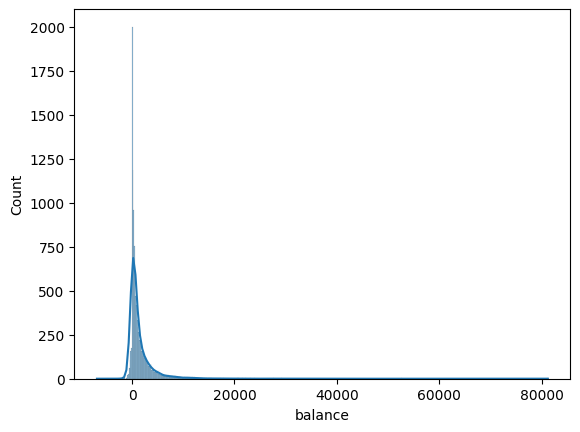

In [19]:
sns.histplot(
    df["balance"],
    kde=True
)

**Customer balances are highly right-skewed. Most customers have relatively low account balances, while a small number of customers hold exceptionally high balances. These extreme values should be investigated further and may require special handling during data preprocessing or modeling.**

<Axes: xlabel='deposit', ylabel='balance'>

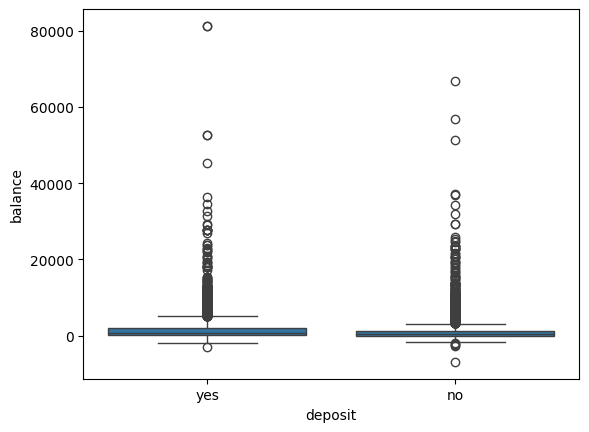

In [20]:
sns.boxplot(
    data=df,
    x="deposit",
    y="balance"
)

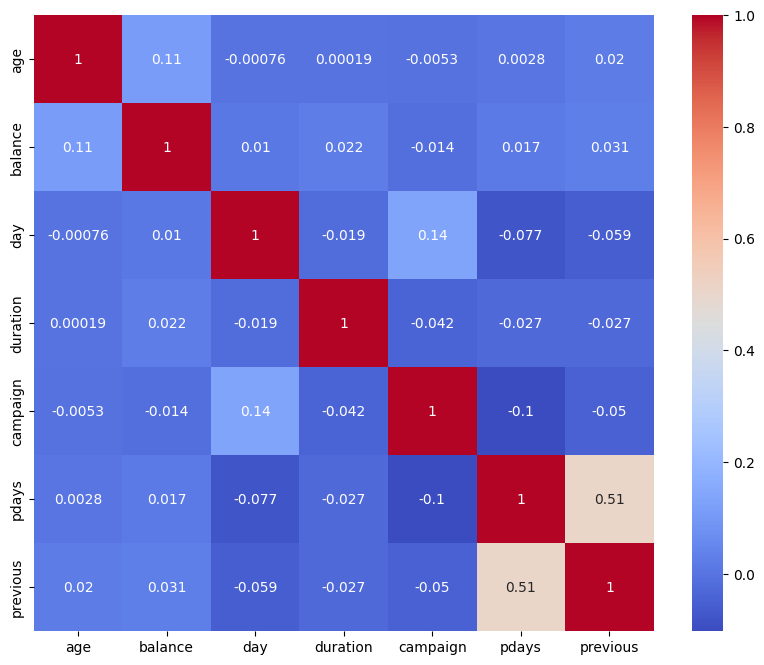

In [21]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

**Most numerical features show weak correlations with the target variable, indicating that customer subscription depends on a combination of multiple factors rather than a single numerical feature.**

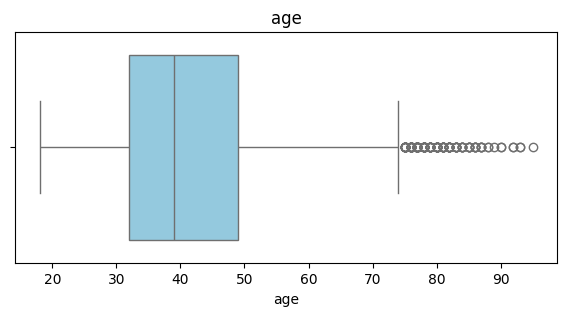

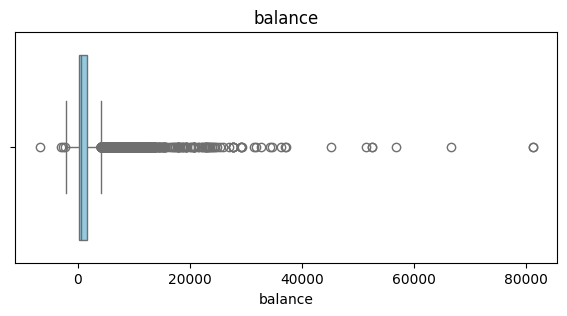

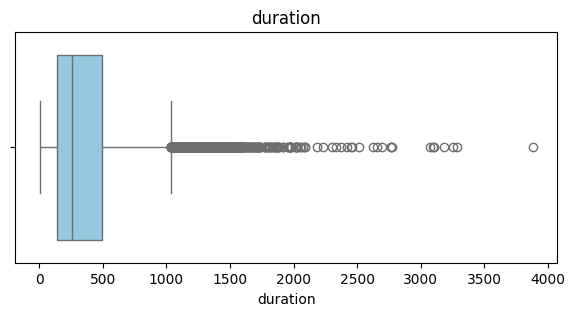

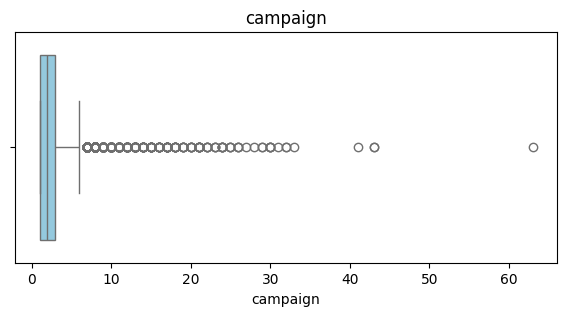

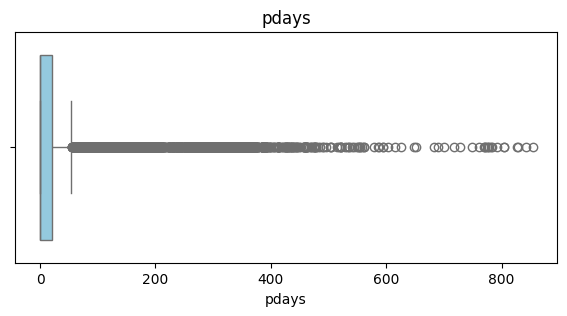

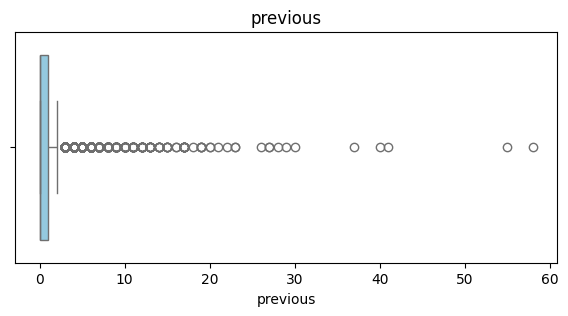

In [22]:
num_cols=[
'age',
'balance',
'duration',
'campaign',
'pdays',
'previous'
]

for col in num_cols:

    plt.figure(figsize=(7,3))

    sns.boxplot(
        x=df[col],
        color='skyblue'

    )

    plt.title(col)

    plt.show()

# **Data Preprocessing**

# **Feature Engineering**

In [23]:
df["never_contacted"] = (df["pdays"] == -1).astype(int)
df["pdays"] = df["pdays"].replace(-1, np.nan)
df["pdays"] = df["pdays"].fillna(0)

**# Handle Outliers**

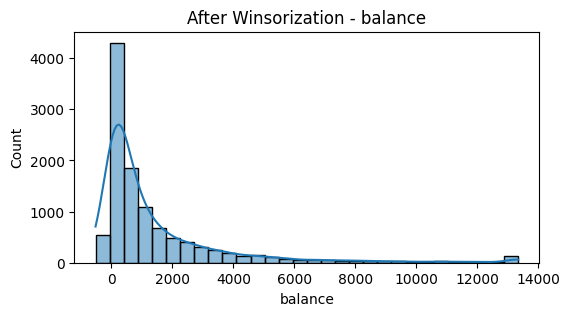

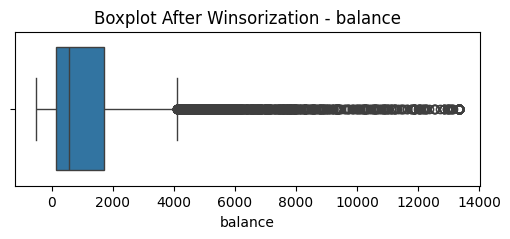

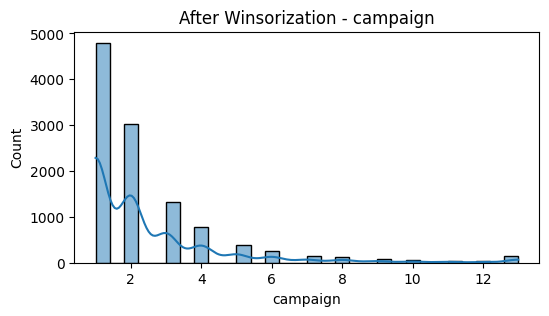

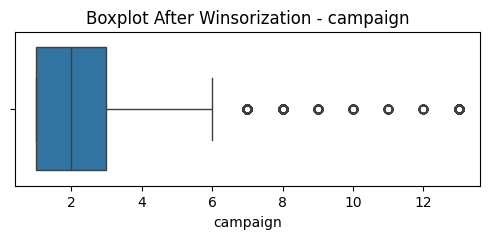

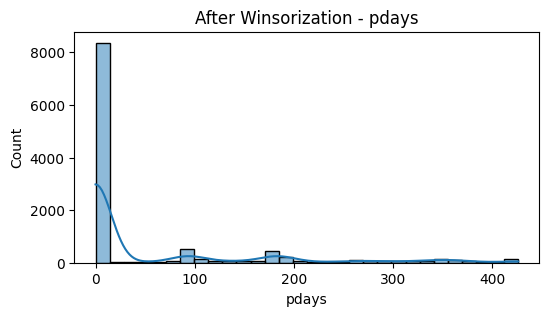

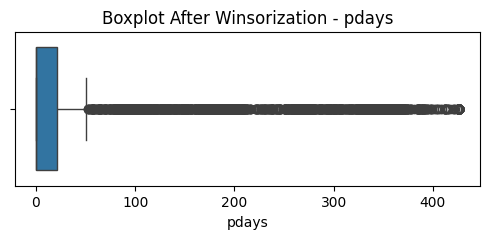

In [24]:
cols = ["balance", "campaign", "pdays"]
for col in cols:
   df[col] = np.array(winsorize(df[col], limits=[0.01, 0.01]))


for col in cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"After Winsorization - {col}")
    plt.show()

    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot After Winsorization - {col}")
    plt.show()

# **Encoding**

In [25]:
month_map = {
    'jan':1,'feb':2,'mar':3,'apr':4,
    'may':5,'jun':6,'jul':7,'aug':8,
    'sep':9,'oct':10,'nov':11,'dec':12
}

df['month'] = df['month'].map(month_map)

In [26]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,never_contacted
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,5,1042,1,0.0,0,unknown,yes,1
1,56,admin.,married,secondary,no,45,no,no,unknown,5,5,1467,1,0.0,0,unknown,yes,1
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,5,1389,1,0.0,0,unknown,yes,1
3,55,services,married,secondary,no,2476,yes,no,unknown,5,5,579,1,0.0,0,unknown,yes,1
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,5,673,2,0.0,0,unknown,yes,1


In [27]:
df.drop("duration", axis=1, inplace=True)


**“duration is known only after call ends → cannot be used in real prediction”**

In [28]:

y = df["deposit"].map({"yes": 1, "no": 0})


X = df.drop("deposit", axis=1)

for col in X.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])


In [29]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,deposit,never_contacted
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,5,1,0.0,0,unknown,yes,1
1,56,admin.,married,secondary,no,45,no,no,unknown,5,5,1,0.0,0,unknown,yes,1
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,5,1,0.0,0,unknown,yes,1
3,55,services,married,secondary,no,2476,yes,no,unknown,5,5,1,0.0,0,unknown,yes,1
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,5,2,0.0,0,unknown,yes,1


In [30]:
df['deposit'].value_counts()

,count
deposit,
no,5873
yes,5289


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 ,stratify=y
)

In [32]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# **Modeling**

In [33]:
model_lg= LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [34]:
model_lg.fit(X_train_s, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [35]:
y_pred_lg = model_lg.predict(X_test_s)

In [36]:
print("Accuracy:", accuracy_score(y_test, y_pred_lg))
print(classification_report(y_test, y_pred_lg))

Accuracy: 0.6636811464397672
              precision    recall  f1-score   support

           0       0.66      0.74      0.70      1175
           1       0.67      0.58      0.62      1058

    accuracy                           0.66      2233
   macro avg       0.66      0.66      0.66      2233
weighted avg       0.66      0.66      0.66      2233



In [37]:
cm = confusion_matrix(y_test, y_pred_lg)
cm_df1 = pd.DataFrame(
    cm,
    index=["Actual : No", "Actual : Yes"],
    columns=["Predicted : No", "Predicted : Yes"]
)
cm_df1


,Predicted : No,Predicted : Yes
Actual : No,865,310
Actual : Yes,441,617


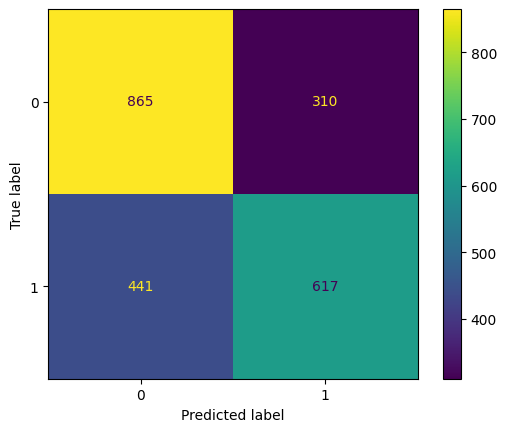

In [38]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lg)
plt.show()

ROC-AUC: 0.7183718778908418


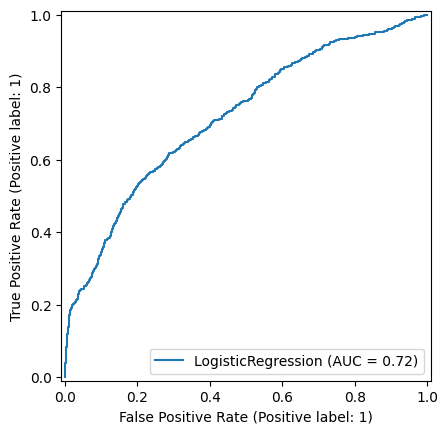

In [39]:
print("ROC-AUC:", roc_auc_score(y_test, model_lg.predict_proba(X_test_s)[:,1]))

RocCurveDisplay.from_estimator(model_lg, X_test_s, y_test)
plt.show()

**Logistic Regression achieved lower performance than the tree-based models, indicating that the dataset contains nonlinear relationships.**

In [40]:
model_rf= RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

model_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, n_estimators=300, random_state=42)

In [41]:
y_pred_rf = model_rf.predict(X_test)

In [42]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.728616211374832
              precision    recall  f1-score   support

           0       0.71      0.82      0.76      1175
           1       0.76      0.63      0.69      1058

    accuracy                           0.73      2233
   macro avg       0.73      0.72      0.72      2233
weighted avg       0.73      0.73      0.73      2233



In [43]:
cm = confusion_matrix(y_test, y_pred_rf)
cm_df1 = pd.DataFrame(
    cm,
    index=["Actual : No", "Actual : Yes"],
    columns=["Predicted : No", "Predicted : Yes"]
)
cm_df1


,Predicted : No,Predicted : Yes
Actual : No,958,217
Actual : Yes,389,669


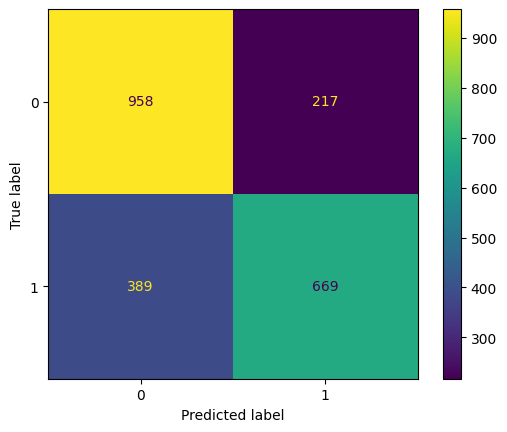

In [44]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.show()

In [45]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model_rf.feature_importances_
})

importance = importance.sort_values("Importance", ascending=False)

print("model_rf:", importance.head(10))

model_rf:      Feature  Importance
10     month    0.130455
8    contact    0.123330
5    balance    0.105595
0        age    0.098437
12     pdays    0.095439
9        day    0.091168
14  poutcome    0.087552
6    housing    0.065936
13  previous    0.042585
11  campaign    0.041163


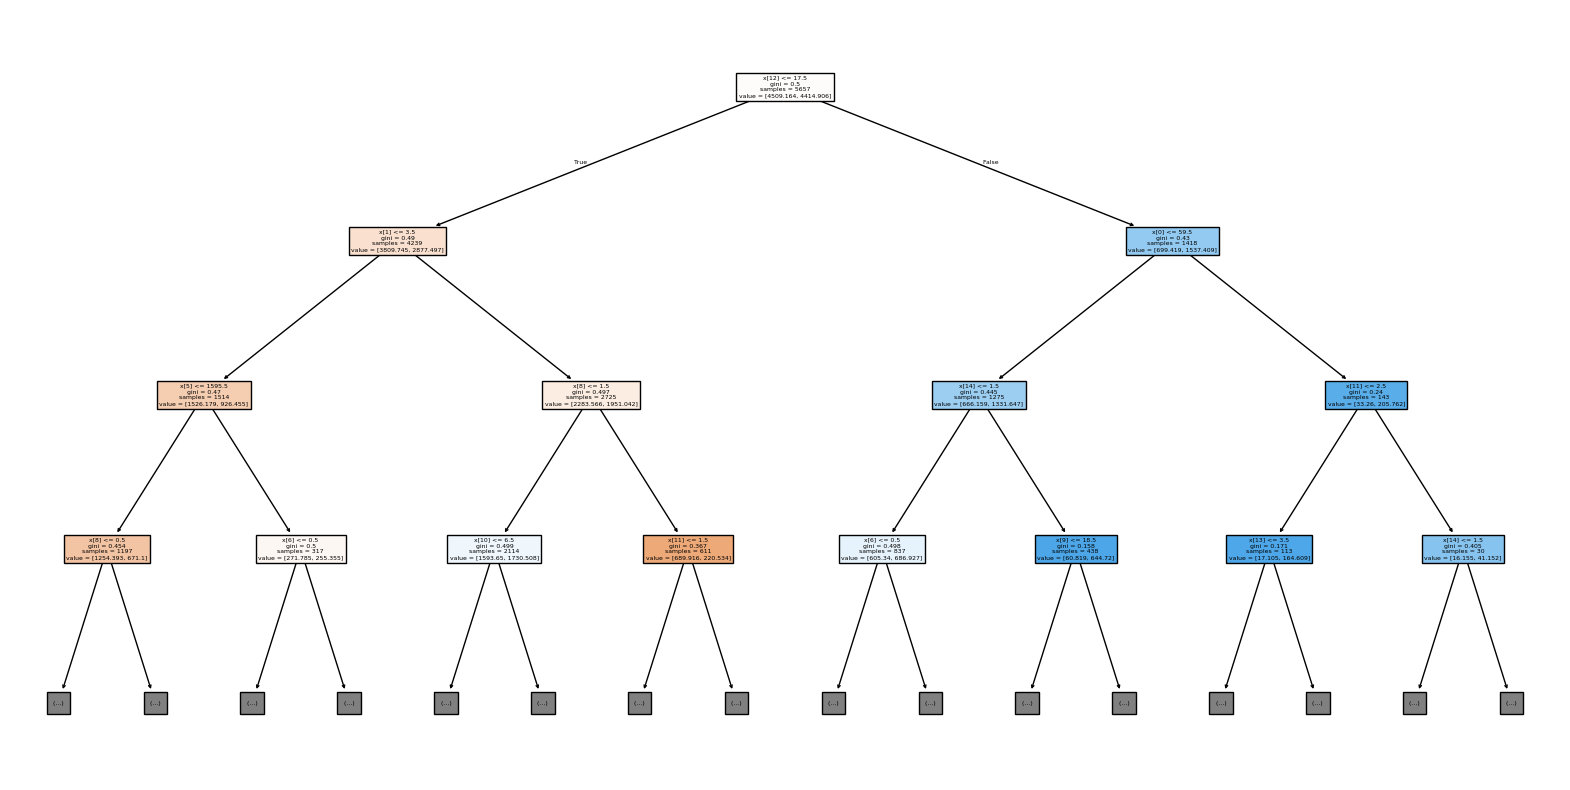

In [46]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    model_rf.estimators_[0],
    max_depth=3,
    filled=True
)

plt.show()

**month, contact, and balance were among the most influential features used by the Random Forest model.**

In [47]:
model_xgb= XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)


In [48]:

model_xgb.fit(X_train, y_train)



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [49]:
y_pred_xgb = model_xgb.predict(X_test)



In [50]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.7272727272727273
              precision    recall  f1-score   support

           0       0.71      0.80      0.76      1175
           1       0.75      0.64      0.69      1058

    accuracy                           0.73      2233
   macro avg       0.73      0.72      0.72      2233
weighted avg       0.73      0.73      0.73      2233



In [51]:
cm = confusion_matrix(y_test, y_pred_xgb)
cm_df1 = pd.DataFrame(
    cm,
    index=["Actual : No", "Actual : Yes"],
    columns=["Predicted : No", "Predicted : Yes"]
)
cm_df1

,Predicted : No,Predicted : Yes
Actual : No,943,232
Actual : Yes,377,681


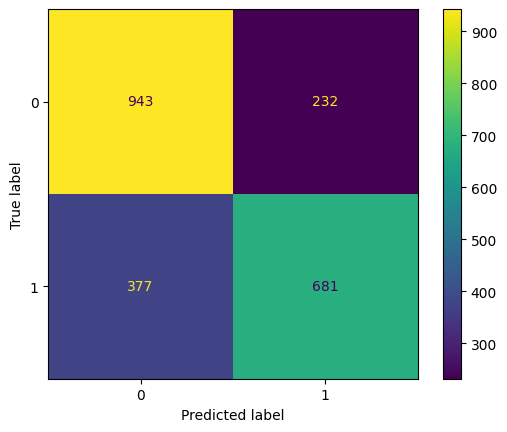

In [52]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)
plt.show()

ROC-AUC: 0.7833575996460604


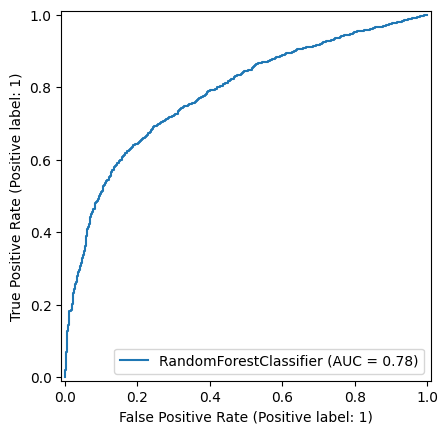

In [53]:
print("ROC-AUC:", roc_auc_score(y_test, model_rf.predict_proba(X_test)[:,1]))

RocCurveDisplay.from_estimator(model_rf, X_test, y_test)
plt.show()

In [54]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model_xgb.feature_importances_
})

importance = importance.sort_values("Importance", ascending=False)

print("model_rf:",importance.head(10))

model_rf:             Feature  Importance
15  never_contacted    0.702769
8           contact    0.061689
14         poutcome    0.046440
6           housing    0.026255
10            month    0.022113
7              loan    0.018382
12            pdays    0.015982
13         previous    0.014587
9               day    0.014416
2           marital    0.012396


**The feature never_contacted was by far the most important predictor, suggesting that whether a client had previously been contacted strongly influences subscription behavior.**

ROC-AUC: 0.7828299078952661


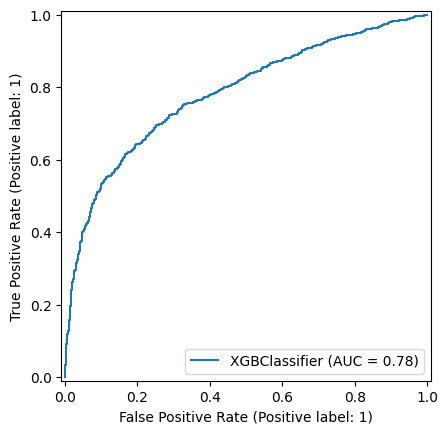

In [55]:
print("ROC-AUC:", roc_auc_score(y_test, model_xgb.predict_proba(X_test)[:,1]))

RocCurveDisplay.from_estimator(model_xgb, X_test, y_test)
plt.show()

In [56]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [0.663681, 0.728616, 0.727273],
    "Precision": [0.67, 0.76, 0.75],
    "Recall": [0.58, 0.63, 0.64],
    "F1-Score": [0.62, 0.69, 0.69]
})

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.663681,0.67,0.58,0.62
1,Random Forest,0.728616,0.76,0.63,0.69
2,XGBoost,0.727273,0.75,0.64,0.69


/tmp/ipykernel_18128/1801115837.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


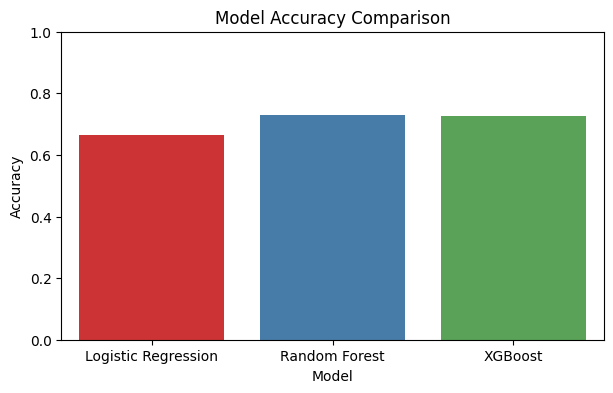

In [57]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy",
    palette='Set1'
)

plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)

plt.show()

**Logistic Regression achieved the lowest performance with an accuracy of 66.4%.**

**Random Forest achieved the highest accuracy (72.9%) and precision (76%).**

**XGBoost achieved similar performance to Random Forest with slightly higher recall for the positive class.**

**Random Forest was selected as the final model because it achieved the best balance between precision and recall and provided more stable performance compared to XGBoost across multiple metrics.**

In [58]:
print(roc_auc_score(y_test, model_lg.predict_proba(X_test_s)[:,1]))
print(roc_auc_score(y_test, model_rf.predict_proba(X_test)[:,1]))
print(roc_auc_score(y_test, model_xgb.predict_proba(X_test)[:,1]))

0.7183718778908418
0.7833575996460604
0.7828299078952661


In [59]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model_rf, X_train, y_train, cv=5, scoring='f1')
print(scores.mean())

0.6917190287511243


In [60]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [8, 10, 12],
    "min_samples_leaf": [3, 5]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid,
                    scoring="f1",
                    cv=3)

grid.fit(X_train, y_train)
print(grid.best_params_)

{'max_depth': 12, 'min_samples_leaf': 3, 'n_estimators': 300}


# **Conclusion**

**• Three machine learning models were evaluated.**

**• Logistic Regression served as a baseline model.**

**• Random Forest achieved the best overall balance between Precision, Recall, F1-score, and ROC-AUC.**

**• Cross-validation confirmed that the model generalizes well.**

**• Hyperparameter tuning was performed using GridSearchCV.**

**• The final model can help banks identify customers who are more likely to subscribe to a term deposit, reducing unnecessary marketing costs.**